# Golf Swing Preprocessing

This notebook implements the color-style normalization pipeline for golfer imagery and packages it into reusable helpers to preprocess entire folders of frames prior to model training.

## Pipeline Overview (Video → Frames)

1. **Frame Extraction** – every input video is decoded frame-by-frame so temporal info is preserved while we normalize appearance.
2. **Reference Style Stats** – a representative frame (auto-picked or supplied) is converted to LAB space to capture mean/std per channel.
3. **Color Style Transfer** – each incoming frame is matched to the reference LAB statistics so indoor/outdoor lighting shifts are reduced.
4. **Basic Normalization** – per-channel standardization guards against extreme brightness swings on noisy frames.
5. **CLAHE Boost** – adaptive histogram equalization enhances local contrast without blowing out highlights.
6. **Visualization + Export** – we stitch preview grids for QA and persist normalized frames (optionally recombine to video downstream).

In [33]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import cv2
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from tqdm import tqdm

PreviewPair = Tuple[np.ndarray, np.ndarray]

In [34]:
VIDEO_DATASET_ROOT = Path("augmented_videos")
VIDEO_FILE_PATTERNS: Tuple[str, ...] = ("*.mp4", "*.mov", "*.avi", "*.mkv")
selected_video_path: Optional[Path] = None
video_files: List[Path] = []


def _scan_videos(root: Path, patterns: Iterable[str]) -> List[Path]:
    files: List[Path] = []
    if root.exists():
        for pattern in patterns:
            files.extend(root.rglob(pattern))
    return sorted(files)


def _format_video_option(path: Path) -> str:
    try:
        rel = path.relative_to(VIDEO_DATASET_ROOT)
        return rel.as_posix()
    except ValueError:
        return path.as_posix()


def show_video_dropdown() -> None:
    global video_files
    video_files = _scan_videos(VIDEO_DATASET_ROOT, VIDEO_FILE_PATTERNS)

    if not video_files:
        print(
            f"No videos with extensions {VIDEO_FILE_PATTERNS} found under {VIDEO_DATASET_ROOT.resolve()}."
        )
        return

    dropdown = widgets.Dropdown(
        options=[(_format_video_option(p), str(p)) for p in video_files],
        value=str(video_files[0]),
        description="Video",
        layout=widgets.Layout(width="80%"),
    )
    selection_label = widgets.HTML()

    def _set_selected(path_str: str) -> None:
        global selected_video_path
        selected_video_path = Path(path_str)
        try:
            rel = selected_video_path.relative_to(VIDEO_DATASET_ROOT)
            selection_label.value = f"Selected: <code>{rel}</code>"
        except ValueError:
            selection_label.value = f"Selected: <code>{selected_video_path}</code>"

    _set_selected(dropdown.value)
    dropdown.observe(
        lambda change: _set_selected(change["new"]) if change["name"] == "value" else None,
        names="value",
    )

    display(
        widgets.VBox(
            [
                widgets.HTML("<b>Choose a source video (frame-wise preprocessing)</b>"),
                dropdown,
                selection_label,
            ]
        )
    )


show_video_dropdown()

In [35]:
class StylePreprocessor:
    """Color-style normalization for single BGR frames decoded from golfer swing videos."""

    def __init__(self, reference_image: Optional[np.ndarray] = None) -> None:
        """Optionally seed the pipeline with a representative frame to anchor style stats."""
        self.reference_image = reference_image
        self.reference_stats: Optional[Dict[str, float]] = None

        if reference_image is not None:
            self.compute_reference_stats(reference_image)

    @staticmethod
    def _calculate_stats(lab_image: np.ndarray) -> Dict[str, float]:
        return {
            "mean_l": float(np.mean(lab_image[:, :, 0])),
            "std_l": float(np.std(lab_image[:, :, 0])),
            "mean_a": float(np.mean(lab_image[:, :, 1])),
            "std_a": float(np.std(lab_image[:, :, 1])),
            "mean_b": float(np.mean(lab_image[:, :, 2])),
            "std_b": float(np.std(lab_image[:, :, 2])),
        }

    def compute_reference_stats(self, image: np.ndarray) -> Dict[str, float]:
        """Convert a reference frame to LAB space and store its per-channel mean/std."""
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        self.reference_stats = self._calculate_stats(lab)
        return self.reference_stats

    def match_color_style(self, image: np.ndarray) -> np.ndarray:
        """Align an incoming frame's LAB distribution with the reference statistics."""
        if self.reference_stats is None:
            return self.normalize_basic(image)

        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB).astype(np.float32)
        input_stats = self._calculate_stats(lab)

        def _match_channel(channel: np.ndarray, key_mean: str, key_std: str) -> np.ndarray:
            input_mean = input_stats[key_mean]
            input_std = input_stats[key_std]
            ref_mean = self.reference_stats[key_mean]
            ref_std = self.reference_stats[key_std]
            safe_std = input_std if input_std > 1e-6 else 1.0  # Avoid dividing by tiny std values
            return (channel - input_mean) * (ref_std / safe_std) + ref_mean

        lab[:, :, 0] = _match_channel(lab[:, :, 0], "mean_l", "std_l")
        lab[:, :, 1] = _match_channel(lab[:, :, 1], "mean_a", "std_a")
        lab[:, :, 2] = _match_channel(lab[:, :, 2], "mean_b", "std_b")

        lab = np.clip(lab, 0, 255).astype(np.uint8)
        return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    def normalize_basic(self, image: np.ndarray, target_mean: float = 128, target_std: float = 50) -> np.ndarray:
        """Standardize each color channel so per-frame brightness/contrast stay predictable."""
        img_float = image.astype(np.float32)

        for idx in range(3):
            channel = img_float[:, :, idx]
            mean = float(np.mean(channel))
            std = float(np.std(channel))
            if std > 1e-6:
                img_float[:, :, idx] = ((channel - mean) / std) * target_std + target_mean

        return np.clip(img_float, 0, 255).astype(np.uint8)

    def apply_clahe(self, image: np.ndarray, clip_limit: float = 2.0, tile_size: tuple[int, int] = (8, 8)) -> np.ndarray:
        """Boost local contrast via CLAHE on the L channel so swing silhouettes pop."""
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    @staticmethod
    def boost_contrast(image: np.ndarray, alpha: float = 1.0, beta: float = 0.0) -> np.ndarray:
        """Apply linear contrast/brightness adjustments (alpha gain + beta offset)."""
        return cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

    @staticmethod
    def adjust_gamma(image: np.ndarray, gamma: float = 1.0) -> np.ndarray:
        """Perform gamma correction to raise shadows (gamma < 1) or tame highlights."""
        gamma = max(gamma, 1e-6)
        inv_gamma = 1.0 / gamma
        table = np.array([(i / 255.0) ** inv_gamma * 255 for i in range(256)]).astype("uint8")
        return cv2.LUT(image, table)

    def preprocess_for_training(
        self,
        image: np.ndarray,
        apply_clahe: bool = True,
        contrast_alpha: float = 1.25,
        contrast_beta: float = 15.0,
        gamma: float = 0.9,
    ) -> np.ndarray:
        """Full per-frame pipeline with optional CLAHE, contrast gain, and gamma lift."""
        processed = self.match_color_style(image)
        if apply_clahe:
            processed = self.apply_clahe(processed)

        if not np.isclose(contrast_alpha, 1.0) or not np.isclose(contrast_beta, 0.0):
            processed = self.boost_contrast(processed, alpha=contrast_alpha, beta=contrast_beta)

        if not np.isclose(gamma, 1.0):
            processed = self.adjust_gamma(processed, gamma=gamma)

        return processed

    def visualize_preprocessing(self, image: np.ndarray) -> Dict[str, np.ndarray]:
        """Return intermediary frames plus a matplotlib grid for quick qualitative QA."""
        color_matched = self.match_color_style(image)
        clahe_img = self.apply_clahe(color_matched)
        contrast_img = self.boost_contrast(clahe_img, alpha=1.25, beta=15.0)
        gamma_img = self.adjust_gamma(contrast_img, gamma=0.9)

        steps = {
            "Original": image,
            "Color Matched": color_matched,
            "CLAHE Applied": clahe_img,
            "Contrast Boosted": contrast_img,
            "Gamma Adjusted": gamma_img,
            "Full Pipeline": self.preprocess_for_training(image),
        }

        fig, axes = plt.subplots(2, 3, figsize=(14, 9))
        axes = axes.ravel()
        for idx, (name, img) in enumerate(steps.items()):
            if idx >= len(axes):
                break
            axes[idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            axes[idx].set_title(name)
            axes[idx].axis("off")
        plt.tight_layout()
        return steps

In [36]:
def collect_image_files(root: Path, extensions: Iterable[str] = ("*.jpg", "*.jpeg", "*.png")) -> List[Path]:
    files: List[Path] = []
    for pattern in extensions:
        files.extend(root.rglob(pattern))
    return sorted(files)


def load_reference_image(reference_path: Optional[Path], candidates: List[Path]) -> np.ndarray:
    if reference_path is not None:
        ref_path = reference_path
    elif candidates:
        ref_path = candidates[0]
    else:
        raise ValueError("No images available to derive a reference style.")

    image = cv2.imread(str(ref_path))
    if image is None:
        raise FileNotFoundError(f"Failed to load reference image at {ref_path}.")
    return image


def preprocess_dataset(
    input_root: Path,
    output_root: Path,
    reference_image_path: Optional[Path] = None,
    apply_clahe: bool = True,
    overwrite: bool = False,
    contrast_alpha: float = 1.25,
    contrast_beta: float = 15.0,
    gamma: float = 0.9,
) -> Dict[str, float]:
    image_files = collect_image_files(input_root)
    if not image_files:
        raise ValueError(f"No images found under {input_root}.")

    reference_image = load_reference_image(reference_image_path, image_files)
    preprocessor = StylePreprocessor(reference_image)

    for image_path in tqdm(image_files, desc="Preprocessing", unit="img"):
        relative = image_path.relative_to(input_root)
        destination = output_root / relative
        destination.parent.mkdir(parents=True, exist_ok=True)

        if destination.exists() and not overwrite:
            continue

        image = cv2.imread(str(image_path))
        if image is None:
            continue

        processed = preprocessor.preprocess_for_training(
            image,
            apply_clahe=apply_clahe,
            contrast_alpha=contrast_alpha,
            contrast_beta=contrast_beta,
            gamma=gamma,
        )
        cv2.imwrite(str(destination), processed)

    return preprocessor.reference_stats or {}


def preprocess_video_frames(
    video_path: Path,
    output_root: Path,
    reference_image_path: Optional[Path] = None,
    frame_skip: int = 1,
    apply_clahe: bool = True,
    overwrite: bool = True,
    preview_frame_count: int = 6,
    contrast_alpha: float = 1.25,
    contrast_beta: float = 15.0,
    gamma: float = 0.9,
    write_video: bool = True,
    video_codec: str = "mp4v",
    video_extension: str = ".mp4",
) -> Dict[str, object]:
    """Decode a video, normalize each sampled frame, and persist both data and previews."""
    if frame_skip < 1:
        raise ValueError("frame_skip must be >= 1.")

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Unable to open video at {video_path}.")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if not fps or fps <= 0:
        fps = 30.0

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    progress_total = total_frames if total_frames > 0 else None
    progress = tqdm(total=progress_total, desc=f"Video {video_path.name}", unit="frame")

    output_dir = output_root / video_path.stem
    output_dir.mkdir(parents=True, exist_ok=True)

    reference_image: Optional[np.ndarray] = None
    if reference_image_path is not None:
        reference_image = cv2.imread(str(reference_image_path))
        if reference_image is None:
            raise FileNotFoundError(f"Failed to load reference frame at {reference_image_path}.")

    preprocessor: Optional[StylePreprocessor] = None
    preview_pairs: List[PreviewPair] = []
    saved_frames = 0
    frame_idx = 0
    video_writer: Optional[cv2.VideoWriter] = None
    rendered_video_path: Optional[Path] = None

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_idx % frame_skip == 0:
                if preprocessor is None:
                    ref_image = reference_image if reference_image is not None else frame
                    preprocessor = StylePreprocessor(ref_image)

                processed = preprocessor.preprocess_for_training(
                    frame,
                    apply_clahe=apply_clahe,
                    contrast_alpha=contrast_alpha,
                    contrast_beta=contrast_beta,
                    gamma=gamma,
                )
                destination = output_dir / f"{video_path.stem}_{saved_frames:05d}.jpg"
                if not destination.exists() or overwrite:
                    cv2.imwrite(str(destination), processed)

                if len(preview_pairs) < preview_frame_count:
                    preview_pairs.append((frame.copy(), processed.copy()))

                if write_video:
                    if video_writer is None:
                        fourcc = cv2.VideoWriter_fourcc(*video_codec)
                        rendered_video_path = output_dir / f"{video_path.stem}_normalized{video_extension}"
                        frame_size = (processed.shape[1], processed.shape[0])
                        video_writer = cv2.VideoWriter(
                            str(rendered_video_path),
                            fourcc,
                            float(fps),
                            frame_size,
                        )
                    video_writer.write(processed)

                saved_frames += 1

            frame_idx += 1
            progress.update(1)
    finally:
        cap.release()
        if video_writer is not None:
            video_writer.release()
        progress.close()

    if preprocessor is None:
        raise RuntimeError("No frames were processed. Check frame_skip or video integrity.")

    return {
        "stats": preprocessor.reference_stats or {},
        "frames_saved": saved_frames,
        "preview_pairs": preview_pairs,
        "preprocessor": preprocessor,
        "output_dir": output_dir,
        "video_path": rendered_video_path,
    }

In [40]:
INPUT_ROOT = Path("TDTU-Golf-Pose-v1/Public Test")
OUTPUT_ROOT = Path("preprocessed_dataset/Public Test")
REFERENCE_IMAGE_PATH: Optional[Path] = None  # Point to a curated frame to anchor style, if desired.
APPLY_CLAHE = True
OVERWRITE_EXISTING = False
EXECUTE_PREPROCESSING = False

# Global tone-mapping and video-output controls
CONTRAST_ALPHA = 1.25  # >1 amplifies contrast
CONTRAST_BETA = 20   # positive values brighten mid-tones
GAMMA_CORRECTION = 0.9  # <1 lifts shadows
WRITE_VIDEO = True
VIDEO_CODEC = "mp4v"
VIDEO_EXTENSION = ".mp4"

if EXECUTE_PREPROCESSING:
    stats = preprocess_dataset(
        input_root=INPUT_ROOT,
        output_root=OUTPUT_ROOT,
        reference_image_path=REFERENCE_IMAGE_PATH,
        apply_clahe=APPLY_CLAHE,
        overwrite=OVERWRITE_EXISTING,
        contrast_alpha=CONTRAST_ALPHA,
        contrast_beta=CONTRAST_BETA,
        gamma=GAMMA_CORRECTION,
    )
    print("Preprocessing complete.")
    print(stats)
else:
    print("Set EXECUTE_PREPROCESSING = True to run the pipeline once paths are verified.")

Set EXECUTE_PREPROCESSING = True to run the pipeline once paths are verified.


In [41]:
DEFAULT_VIDEO_PATH = Path("augmented_videos/sample_clip.mp4")
VIDEO_PATH = (
    Path(selected_video_path)
    if "selected_video_path" in globals()
    and selected_video_path is not None
    and Path(selected_video_path).exists()
    else DEFAULT_VIDEO_PATH
)
VIDEO_OUTPUT_ROOT = Path("preprocessed_dataset/videos")
VIDEO_REFERENCE_FRAME: Optional[Path] = None  # Optional still frame to lock style across shots.
FRAME_SKIP = 1  # Process every frame by default; bump to >1 for speed.
PREVIEW_FRAME_COUNT = 4
RUN_VIDEO_PREPROCESSING = True

VIDEO_PREVIEW: List[PreviewPair] = []
VIDEO_PREPROCESSOR: Optional[StylePreprocessor] = None
VIDEO_RUN_SUMMARY: Dict[str, object] = {}

if VIDEO_PATH.exists():
    print(f"Video source: {VIDEO_PATH}")
else:
    print(f"Warning: video source {VIDEO_PATH} does not exist. Update the dropdown or fallback path.")

print(
    f"Tone controls → alpha={CONTRAST_ALPHA}, beta={CONTRAST_BETA}, gamma={GAMMA_CORRECTION} | write_video={WRITE_VIDEO}"
)

if RUN_VIDEO_PREPROCESSING:
    video_result = preprocess_video_frames(
        video_path=VIDEO_PATH,
        output_root=VIDEO_OUTPUT_ROOT,
        reference_image_path=VIDEO_REFERENCE_FRAME,
        frame_skip=FRAME_SKIP,
        apply_clahe=APPLY_CLAHE,
        overwrite=OVERWRITE_EXISTING,
        preview_frame_count=PREVIEW_FRAME_COUNT,
        contrast_alpha=CONTRAST_ALPHA,
        contrast_beta=CONTRAST_BETA,
        gamma=GAMMA_CORRECTION,
        write_video=WRITE_VIDEO,
        video_codec=VIDEO_CODEC,
        video_extension=VIDEO_EXTENSION,
    )
    VIDEO_PREVIEW = video_result["preview_pairs"]
    VIDEO_PREPROCESSOR = video_result["preprocessor"]
    VIDEO_RUN_SUMMARY = {
        "frames_saved": video_result["frames_saved"],
        "output_dir": str(video_result["output_dir"]),
        "stats": video_result["stats"],
        "video_path": str(video_result["video_path"]) if video_result["video_path"] else None,
    }
    print(
        f"Processed {VIDEO_RUN_SUMMARY['frames_saved']} frames from {VIDEO_PATH.name} into {VIDEO_RUN_SUMMARY['output_dir']}."
    )
    if VIDEO_RUN_SUMMARY["video_path"]:
        print(f"Rendered video: {VIDEO_RUN_SUMMARY['video_path']}")
    print(f"Reference stats: {VIDEO_RUN_SUMMARY['stats']}")
else:
    print("Set RUN_VIDEO_PREPROCESSING = True once the selected source clip is correct.")

Video source: augmented_videos\augmented_00.mp4
Tone controls → alpha=1.25, beta=20, gamma=0.9 | write_video=True


Video augmented_00.mp4: 100%|██████████| 213/213 [00:17<00:00, 11.96frame/s]

Processed 213 frames from augmented_00.mp4 into preprocessed_dataset\videos\augmented_00.
Rendered video: preprocessed_dataset\videos\augmented_00\augmented_00_normalized.mp4
Reference stats: {'mean_l': 165.72346245659722, 'std_l': 55.790859947484215, 'mean_a': 120.692734375, 'std_a': 9.764208716709774, 'mean_b': 137.28395182291666, 'std_b': 17.619828297314523}


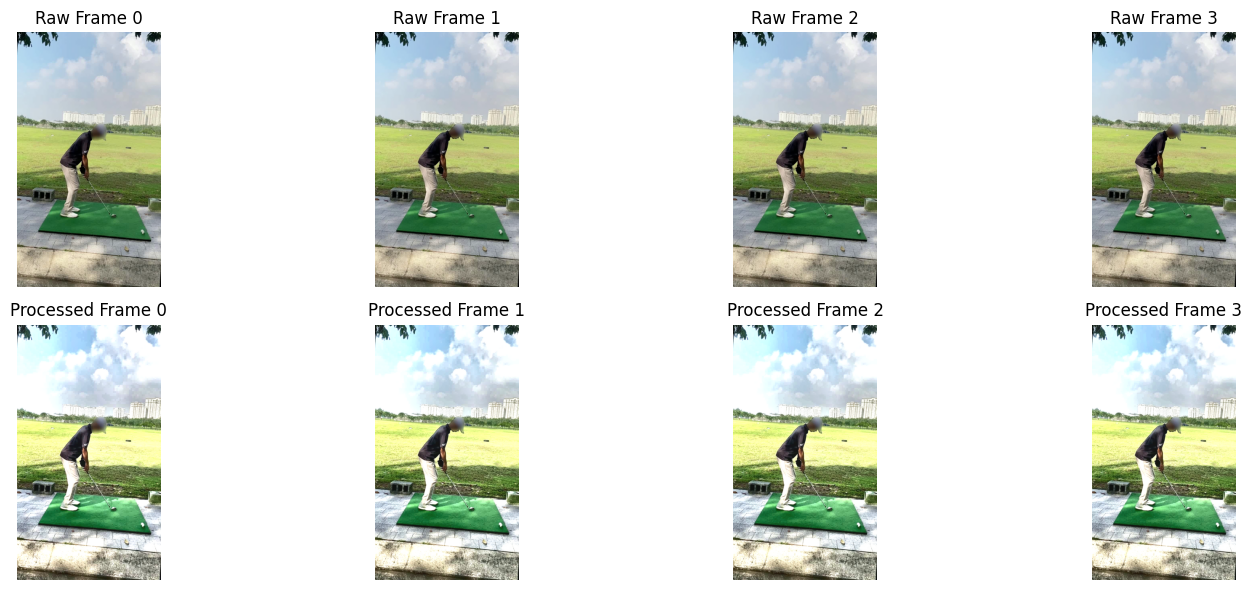

Pipeline breakdown for preview frame 0:


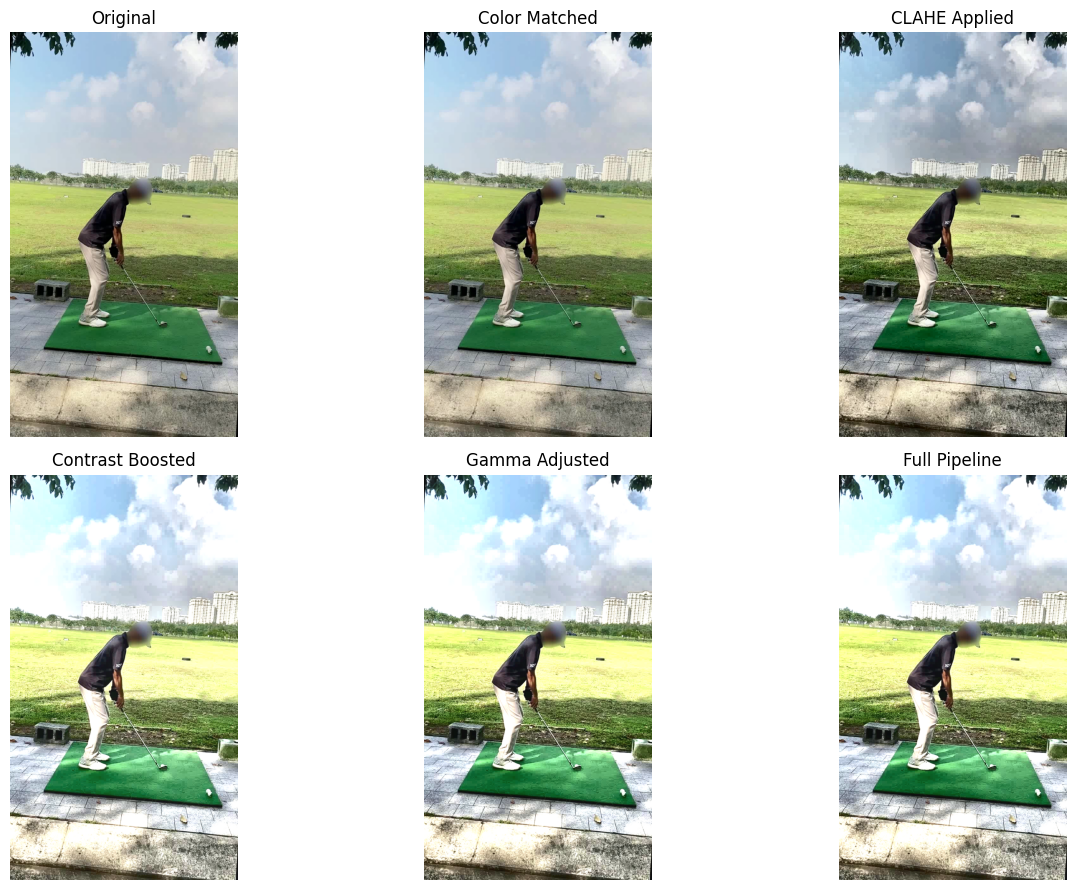

In [42]:
SAMPLE_IMAGE_PATH: Optional[Path] = None  # Fallback still image for manual inspection.

if VIDEO_PREVIEW:
    cols = len(VIDEO_PREVIEW)
    fig, axes = plt.subplots(2, cols, figsize=(4 * cols, 6))
    for idx, (raw_frame, processed_frame) in enumerate(VIDEO_PREVIEW):
        axes[0, idx].imshow(cv2.cvtColor(raw_frame, cv2.COLOR_BGR2RGB))
        axes[0, idx].set_title(f"Raw Frame {idx}")
        axes[0, idx].axis("off")

        axes[1, idx].imshow(cv2.cvtColor(processed_frame, cv2.COLOR_BGR2RGB))
        axes[1, idx].set_title(f"Processed Frame {idx}")
        axes[1, idx].axis("off")

    plt.tight_layout()
    plt.show()

    if VIDEO_PREPROCESSOR is not None:
        print("Pipeline breakdown for preview frame 0:")
        VIDEO_PREPROCESSOR.visualize_preprocessing(VIDEO_PREVIEW[0][0])
elif SAMPLE_IMAGE_PATH and SAMPLE_IMAGE_PATH.exists():
    sample_image = cv2.imread(str(SAMPLE_IMAGE_PATH))
    reference_image = load_reference_image(REFERENCE_IMAGE_PATH, collect_image_files(INPUT_ROOT))
    viz_preprocessor = StylePreprocessor(reference_image)
    viz_preprocessor.visualize_preprocessing(sample_image)
else:
    print(
        "Run the video preprocessing cell (or set SAMPLE_IMAGE_PATH) to generate end-to-end visualizations."
    )

### Next Steps

1. Point `VIDEO_PATH` (and optionally `VIDEO_REFERENCE_FRAME`) to your swing clip, then toggle `RUN_VIDEO_PREPROCESSING = True` to normalize every sampled frame.
2. If you already have frames on disk, use the dataset cell by setting `EXECUTE_PREPROCESSING = True` to refresh `preprocessed_dataset/`.
3. Inspect the visualization cell after each run to confirm the color-match, normalization, and CLAHE stages look correct before training or recombining frames back into video form.